aplicaremos metodos de regularizacion y de optimizacion a los lab que me parecieron mas complejos, para evitar el sobreajuste

ahora dividiremos de forma correcta las celdas necesarias para poder comprender mejor el tratamiento de un dt, la implementacion del modelo y las formas de interpretarlo

importacion de librerias, tanto para realizar formulas matematicas, graficaciones, matrices y tensores para cuda

In [1]:
# Manejo de directorios y rutas
import os

# Computación numérica y manejo de matrices
import numpy as np

# Manejo y preprocesamiento de datos
import pandas as pd

# Librerías para graficación
from matplotlib import pyplot

# Mostrar gráficos dentro del cuadernillo
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("CUDA de PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

#si queremos mejorar este codigo deberiamos de usar el siguiente para que se use cuda siempre y cuando existan esos nuvles y si no permanecer en cpu
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#print(f'Dispositivo en uso: {device}')
#print(f'Versión de PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cu132
CUDA disponible: True
CUDA de PyTorch: 13.2
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


ahora cargaremos el dataset, analizaremos su estructura, sus variables y rea;izaremos un tratamiento para las aprtes necesarias

cargamos el dt, esta ves usaremos el dt de clasificacion binaria, existen div=bersas formas de tratamiento para este caso ya que el dt esta desbalanceado y contiene variables de tipo cadena

In [4]:
df_lab4 = pd.read_csv("dataset_6/diabetes_dataset.csv")

df_lab4.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


ahora veremos mas informacion del dt como su tamaño y el tipo de variables

In [5]:
df_lab4.shape
df_lab4.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day           10

una vez visto la estructura del dt podemos ver que tipo de tratamiento necesita

In [6]:
# Crear una copia del dataset original
datos_modelo_lab4 = df_lab4.copy()

print("Dataset original:", df_lab4.shape)
print("Copia para el modelo:", datos_modelo_lab4.shape)

Dataset original: (100000, 31)
Copia para el modelo: (100000, 31)


en la copia que realizamos eliminaremos la columna diabetes stage ya que esta columna puede llegar a ser riesgosa para encontrar nuestro objetivo, basicamente indica que tipo de diabtes tiene una persona y nuestro objetivo es ver si la persona tiene diabetes o no

In [7]:
# Eliminar la variable que no utilizaremos
datos_modelo_lab4 = datos_modelo_lab4.drop(columns=["diabetes_stage",])

In [8]:
print("Copia para el modelo:", datos_modelo_lab4.shape)

Copia para el modelo: (100000, 30)


aqui empezamos con el metodo one hot encoding, nos ayudara para subdividir las columnas de tipo texto

In [9]:
# Variables categóricas que vamos a transformar
columnas_categoricas = [
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status",
    "smoking_status",
]

# Convertir variables categóricas a variables numéricas
datos_modelo_lab4 = pd.get_dummies(
    datos_modelo_lab4,
    columns=columnas_categoricas,
    dtype=int
)

In [10]:
print("Copia para el modelo:", datos_modelo_lab4.shape)

Copia para el modelo: (100000, 48)


In [11]:
print ("nuevas columnas:", datos_modelo_lab4.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   alcohol_consumption_per_week        100000 non-null  int64  
 2   physical_activity_minutes_per_week  100000 non-null  int64  
 3   diet_score                          100000 non-null  float64
 4   sleep_hours_per_day                 100000 non-null  float64
 5   screen_time_hours_per_day           100000 non-null  float64
 6   family_history_diabetes             100000 non-null  int64  
 7   hypertension_history                100000 non-null  int64  
 8   cardiovascular_history              100000 non-null  int64  
 9   bmi                                 100000 non-null  float64
 10  waist_to_hip_ratio                  100000 non-null  float64
 11  systolic_bp                         10

hasta el mometno solamente resolvimos el problema de las variables de tipo cadena, ahora cargaremos el dataset, verificaremos el balance

In [12]:
X_lab4 = datos_modelo_lab4.drop(columns=["diagnosed_diabetes"])
y_lab4 = datos_modelo_lab4["diagnosed_diabetes"]

print("Forma de X:", X_lab4.shape)
print("Forma de y:", y_lab4.shape)

print("\nDistribución de clases:")
print(y_lab4.value_counts())

Forma de X: (100000, 47)
Forma de y: (100000,)

Distribución de clases:
diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64


hemos comprobado que las clases estan desbalanceadas, ahora dividiremos el dt en train y test tomadno valores de 80% y 20%, luego balancearemos las clases

In [13]:
from sklearn.model_selection import train_test_split

X_train_lab4, X_test_lab4, y_train_lab4, y_test_lab4 = train_test_split(
    X_lab4, y_lab4,
    test_size=0.20,
    random_state=42,
    stratify=y_lab4
)

# NUEVO: partimos train en train/val
X_train_lab4, X_val_lab4, y_train_lab4, y_val_lab4 = train_test_split(
    X_train_lab4, y_train_lab4,
    test_size=0.125,
    random_state=42,
    stratify=y_train_lab4
)

print("X_train:", X_train_lab4.shape)
print("X_val:", X_val_lab4.shape)
print("X_test:", X_test_lab4.shape)
print("y_train:", y_train_lab4.shape)
print("y_val:", y_val_lab4.shape)
print("y_test:", y_test_lab4.shape)

X_train: (70000, 47)
X_val: (10000, 47)
X_test: (20000, 47)
y_train: (70000,)
y_val: (10000,)
y_test: (20000,)


verificames el desbalance con la division ya reaizada

In [14]:
print("Distribución original:")
print(y_lab4.value_counts())
print(y_lab4.value_counts(normalize=True))

print("\nDistribución en TRAIN:")
print(y_train_lab4.value_counts())
print(y_train_lab4.value_counts(normalize=True))

print("\nDistribución en TEST:")
print(y_test_lab4.value_counts())
print(y_test_lab4.value_counts(normalize=True))

Distribución original:
diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64
diagnosed_diabetes
1    0.59998
0    0.40002
Name: proportion, dtype: float64

Distribución en TRAIN:
diagnosed_diabetes
1    41998
0    28002
Name: count, dtype: int64
diagnosed_diabetes
1    0.599971
0    0.400029
Name: proportion, dtype: float64

Distribución en TEST:
diagnosed_diabetes
1    12000
0     8000
Name: count, dtype: int64
diagnosed_diabetes
1    0.6
0    0.4
Name: proportion, dtype: float64


aplicamos el metodo SMOTE para arreglar el desbalance de este dt llevando la clase "pobre" al rango de la clase alta

**investigar cual seria su forma para una version multiclase**

In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.95, random_state=42)

X_train_lab4, y_train_lab4 = smote.fit_resample(
    X_train_lab4,
    y_train_lab4
)

print("Después de SMOTE:")
print("X_train:", X_train_lab4.shape)
print("y_train:", y_train_lab4.shape)

print("\nDistribución de clases:")
print(y_train_lab4.value_counts())

Después de SMOTE:
X_train: (81896, 47)
y_train: (81896,)

Distribución de clases:
diagnosed_diabetes
1    41998
0    39898
Name: count, dtype: int64


In [16]:
print("Después de SMOTE:")
print("y_train:", y_train_lab4.shape)
print("y_train:", y_train_lab4.value_counts())
print("y_train:", y_train_lab4.value_counts(normalize=True))

Después de SMOTE:
y_train: (81896,)
y_train: diagnosed_diabetes
1    41998
0    39898
Name: count, dtype: int64
y_train: diagnosed_diabetes
1    0.512821
0    0.487179
Name: proportion, dtype: float64


ahora realizaremos la funcion de normalizacion y la aplicaremos

In [17]:
def featureNormalize(X):

    X_norm = X.copy()

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [18]:
X_train_lab4_norm, mu_lab4, sigma_lab4 = featureNormalize(X_train_lab4)

X_val_lab4_norm = (X_val_lab4 - mu_lab4) / sigma_lab4
X_test_lab4_norm = (X_test_lab4 - mu_lab4) / sigma_lab4

ahora lelavremos el modelo a cuda, es decir ahora seran tensores 

In [19]:
import torch

X_train_lab4_t = torch.tensor(
    X_train_lab4_norm.to_numpy(),
    dtype=torch.float32
).cuda()

X_test_lab4_t = torch.tensor(
    X_test_lab4_norm.to_numpy(),
    dtype=torch.float32
).cuda()

y_train_lab4_t = torch.tensor(
    y_train_lab4.to_numpy(),
    dtype=torch.float32
).cuda()

y_test_lab4_t = torch.tensor(
    y_test_lab4.to_numpy(),
    dtype=torch.float32
).cuda()


X_val_lab4_t = torch.tensor(
    X_val_lab4_norm.to_numpy(),
    dtype=torch.float32
).cuda()

y_val_lab4_t = torch.tensor(
    y_val_lab4.to_numpy(),
    dtype=torch.float32
).cuda()

**ahora empezaremos con la creacion del modelo**

### Objetivos de esta sección

En esta parte del cuaderno realizaremos las siguientes configuraciones:

1. **Definir el Forward:** Construiremos la estructura que seguirá el modelo usando un módulo `Sequential`.
2. **Configurar el Optimizador:** Inicializaremos la variable de optimización utilizando el algoritmo **Adam**.
3. **Definir la Función de Pérdida (*Loss Function*):** Estableceremos el criterio con el cual evaluaremos el error del modelo.
4. **Fijar Hiperparámetros:** Determinaremos el número de **épocas** (*epochs*) y la tasa de aprendizaje (*learning rate*).
5. **Aplicar Regularización:** Implementaremos técnicas como **L2** (weight decay) y **Dropout** para evitar el sobreajuste (*overfitting*).

In [ ]:
D_in = X_train_lab4_t.shape[1]
H = 100
D_out = 1

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.5),
    torch.nn.Linear(H, D_out)
).to("cuda")

criterion = torch.nn.BCEWithLogitsLoss()


optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 18000
log_each = 100

l_lab4 = []
val_l_lab4 = []          # <<< NUEVO: guardamos la pérdida de validación por epoch

best_val_loss = float("inf")   # <<< NUEVO: mejor pérdida de validación vista hasta ahora
patience = 500                 # <<< NUEVO: epochs de tolerancia sin mejora antes de parar
step = 0                       # <<< NUEVO: contador de epochs sin mejora

model.train()

for e in range(1, epochs + 1):

    model.train()             # <<< NUEVO: aseguramos modo entrenamiento en cada epoch (por el Dropout)

    # Forward
    logits_lab4 = model(X_train_lab4_t)

    # Loss
    loss_lab4 = criterion(
        logits_lab4,
        y_train_lab4_t.reshape(-1, 1)
    )

    l_lab4.append(loss_lab4.item())

    # Reiniciar gradientes
    optimizer.zero_grad()

    # Backpropagation
    loss_lab4.backward()

    # Actualizar pesos
    optimizer.step()

    # <<< NUEVO: bloque completo de validación + early stopping >>>
    model.eval()
    with torch.no_grad():
        val_logits_lab4 = model(X_val_lab4_t)
        val_loss_lab4 = criterion(
            val_logits_lab4,
            y_val_lab4_t.reshape(-1, 1)
        )
    val_l_lab4.append(val_loss_lab4.item())

    if val_loss_lab4.item() < best_val_loss:
        best_val_loss = val_loss_lab4.item()
        torch.save(model.state_dict(), "ckpt_lab4.pt")
        step = 0
    else:
        step += 1

    if step > patience:
        print(f"Early stopping en epoch {e} (sin mejora en {patience} epochs)")
        break
    # <<< FIN bloque nuevo >>>

    if not e % log_each:
        print(
            f"Epoch {e}/{epochs} "
            f"Loss {loss_lab4.item():.5f} "
            f"Val_loss {val_loss_lab4.item():.5f}"     # <<< NUEVO en el print
        )

model.load_state_dict(torch.load("ckpt_lab4.pt"))   # <<< NUEVO: cargamos el mejor modelo al terminar

Epoch 100/18000 Loss 0.34447 Val_loss 0.37764
Epoch 200/18000 Loss 0.28196 Val_loss 0.31601
Epoch 300/18000 Loss 0.25940 Val_loss 0.29471
Epoch 400/18000 Loss 0.24694 Val_loss 0.28154
Epoch 500/18000 Loss 0.23717 Val_loss 0.27188
Epoch 600/18000 Loss 0.23013 Val_loss 0.26397
Epoch 700/18000 Loss 0.22325 Val_loss 0.25769
Epoch 800/18000 Loss 0.21811 Val_loss 0.25245
Epoch 900/18000 Loss 0.21423 Val_loss 0.24799
Epoch 1000/18000 Loss 0.21052 Val_loss 0.24424
Epoch 1100/18000 Loss 0.20732 Val_loss 0.24100
Epoch 1200/18000 Loss 0.20481 Val_loss 0.23830
Epoch 1300/18000 Loss 0.20229 Val_loss 0.23595
Epoch 1400/18000 Loss 0.20023 Val_loss 0.23403
Epoch 1500/18000 Loss 0.19761 Val_loss 0.23218
Epoch 1600/18000 Loss 0.19679 Val_loss 0.23058
Epoch 1700/18000 Loss 0.19537 Val_loss 0.22916
Epoch 1800/18000 Loss 0.19472 Val_loss 0.22772
Epoch 1900/18000 Loss 0.19354 Val_loss 0.22664
Epoch 2000/18000 Loss 0.19186 Val_loss 0.22553
Epoch 2100/18000 Loss 0.19139 Val_loss 0.22479
Epoch 2200/18000 Loss 

<All keys matched successfully>

grafica de costo:

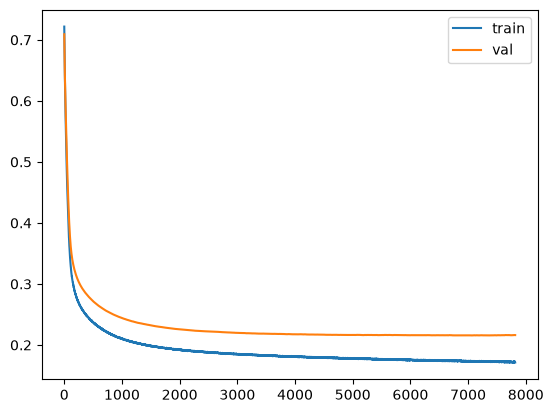

In [25]:
plt.plot(l_lab4, label="train")
plt.plot(val_l_lab4, label="val")
plt.legend()

In [22]:
from sklearn.metrics import accuracy_score

def evaluate_lab4(x):

    model.eval()

    # Forward
    logits = model(x)

    # Convertimos logits en probabilidades
    probabilidades = torch.sigmoid(logits)

    # Aplicamos umbral 0.5
    predicciones = (probabilidades >= 0.5).float()

    return predicciones

In [23]:
y_pred_lab4 = evaluate_lab4(X_test_lab4_t)

accuracy_lab4 = (
    (y_pred_lab4 == y_test_lab4_t.reshape(-1, 1))
    .float()
    .mean()
)

print(f"Accuracy: {accuracy_lab4.item() * 100:.2f}%")

Accuracy: 91.76%


In [24]:
# Evaluación sobre los datos de prueba
model.eval()

with torch.no_grad():

    logits_test_lab4 = model(X_test_lab4_t)

    # Convertimos logits en probabilidades
    probabilidades_test_lab4 = torch.sigmoid(logits_test_lab4)

    # Aplicamos umbral de 0.5
    predicciones_test_lab4 = (
        probabilidades_test_lab4 >= 0.5
    ).float()

# Mostramos algunas predicciones
for i in range(10):

    print(
        f"Real: {y_test_lab4_t[i].item():.0f} "
        f"| Probabilidad: {probabilidades_test_lab4[i].item():.4f} "
        f"| Predicción: {predicciones_test_lab4[i].item():.0f}"
    )

Real: 0 | Probabilidad: 0.1273 | Predicción: 0
Real: 1 | Probabilidad: 1.0000 | Predicción: 1
Real: 0 | Probabilidad: 0.1492 | Predicción: 0
Real: 0 | Probabilidad: 0.1056 | Predicción: 0
Real: 1 | Probabilidad: 1.0000 | Predicción: 1
Real: 0 | Probabilidad: 0.2238 | Predicción: 0
Real: 0 | Probabilidad: 0.2147 | Predicción: 0
Real: 1 | Probabilidad: 0.9989 | Predicción: 1
Real: 0 | Probabilidad: 0.1084 | Predicción: 0
Real: 1 | Probabilidad: 1.0000 | Predicción: 1


# dt rgafico con early stopping

In [3]:
import random

In [4]:
df_emnist = pd.read_csv(
    "dataset_6/emnist-balanced-train.csv",
    header=None
)

print("Forma del dataset:", df_emnist.shape)

Forma del dataset: (112800, 785)


In [ ]:
datos_modelo_emnist = df_emnist.copy()

print("Dataset original:", df_emnist.shape)
print("Copia para el modelo:", datos_modelo_emnist.shape)

Dataset original: (112800, 785)
Copia para el modelo: (112800, 785)


In [ ]:
X_emnist = datos_modelo_emnist.iloc[:, 1:]
y_emnist = datos_modelo_emnist.iloc[:, 0]

print("Forma de X:", X_emnist.shape)
print("Forma de y:", y_emnist.shape)

Forma de X: (112800, 784)
Forma de y: (112800,)


In [ ]:
X_emnist = X_emnist.to_numpy()
y_emnist = y_emnist.to_numpy()

In [ ]:
from sklearn.model_selection import train_test_split

X_train_emnist, X_test_emnist, y_train_emnist, y_test_emnist = train_test_split(
    X_emnist, y_emnist,
    test_size=0.20,
    random_state=42,
    stratify=y_emnist
)

# NUEVO: partimos train en train/val
X_train_emnist, X_val_emnist, y_train_emnist, y_val_emnist = train_test_split(
    X_train_emnist, y_train_emnist,
    test_size=0.125,
    random_state=42,
    stratify=y_train_emnist
)

print("X_train:", X_train_emnist.shape)
print("X_val:", X_val_emnist.shape)
print("X_test:", X_test_emnist.shape)
print("y_train:", y_train_emnist.shape)
print("y_val:", y_val_emnist.shape)
print("y_test:", y_test_emnist.shape)

NameError: name 'X_emnist' is not defined

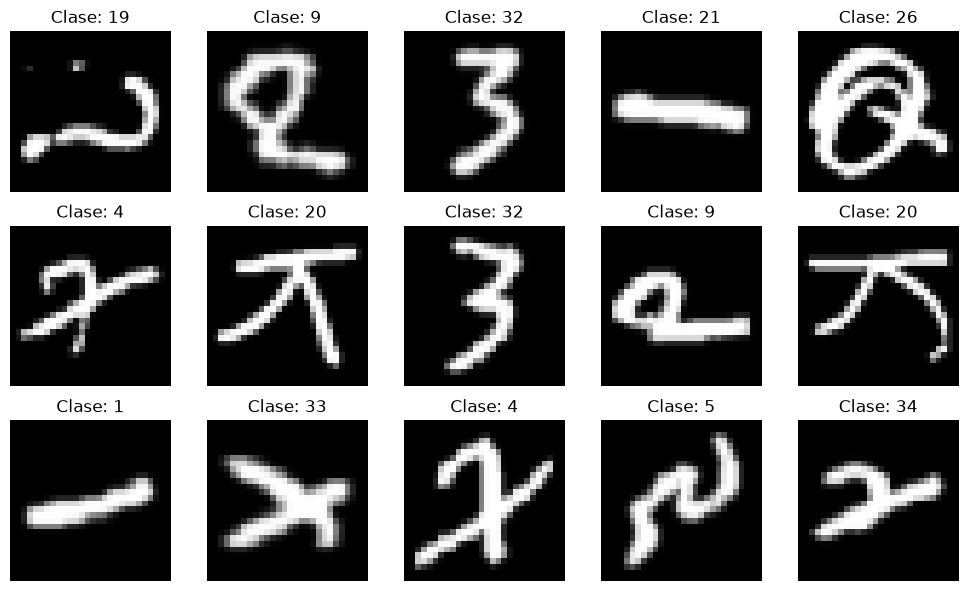

In [9]:
r, c = 3, 5

fig = plt.figure(figsize=(2*c, 2*r))

for _r in range(r):
    for _c in range(c):

        plt.subplot(r, c, _r*c + _c + 1)

        ix = random.randint(0, len(X_train_emnist) - 1)

        img = X_train_emnist[ix]

        plt.imshow(
            img.reshape(28, 28),
            cmap="gray"
        )

        plt.axis("off")
        plt.title(f"Clase: {y_train_emnist[ix]}")

plt.tight_layout()
plt.show()

In [10]:
# Normalizamos los píxeles
X_train_emnist = X_train_emnist / 255.0
X_test_emnist = X_test_emnist / 255.0
x_val_emnist = X_val_emnist / 255.0

# Convertimos las etiquetas a enteros
y_train_emnist = y_train_emnist.astype(np.int64)
y_test_emnist = y_test_emnist.astype(np.int64)
y_val_emnist = y_val_emnist.astype(np.int64)

In [11]:
import torch

X_train_emnist_t = torch.tensor(
    X_train_emnist,
    dtype=torch.float32
).cuda()

X_test_emnist_t = torch.tensor(
    X_test_emnist,
    dtype=torch.float32
).cuda()

y_train_emnist_t = torch.tensor(
    y_train_emnist,
    dtype=torch.long
).cuda()

y_test_emnist_t = torch.tensor(
    y_test_emnist,
    dtype=torch.long
).cuda()

x_val_emnist_t = torch.tensor(
    x_val_emnist,
    dtype=torch.float32
).cuda()

y_val_emnist_t = torch.tensor(
    y_val_emnist,
    dtype=torch.long
).cuda()


In [53]:
D_in, H1, H2, D_out = 784, 250, 200, 47
model_emnist = torch.nn.Sequential(
torch.nn.Linear(D_in, H1),
torch.nn.ReLU(),
torch.nn.Dropout(0.2),
torch.nn.Linear(H1, H2),
torch.nn.ReLU(),
torch.nn.Dropout(0.2),
torch.nn.Linear(H2, D_out),
).cuda()

criterion_emnist = torch.nn.CrossEntropyLoss()


optimizer_emnist = torch.optim.Adam(model_emnist.parameters(), lr=0.008)

epochs = 2000
log_each = 10

l_emnist = []
val_l_emnist = []          # <<< NUEVO: guardamos la pérdida de validación por epoch

best_val_loss = float("inf")   # <<< NUEVO: mejor pérdida de validación vista hasta ahora
patience = 500                 # <<< NUEVO: epochs de tolerancia sin mejora antes de parar
step = 0                       # <<< NUEVO: contador de epochs sin mejora

model_emnist.train()

for e in range(1, epochs + 1):

    model_emnist.train()             # <<< NUEVO: aseguramos modo entrenamiento en cada epoch (por el Dropout)

    # Forward
    y_pred_emnist = model_emnist(X_train_emnist_t)

    # Loss
    loss_emnist = criterion_emnist(
        y_pred_emnist,
        y_train_emnist_t
    )

    l_emnist.append(loss_emnist.item())

    # Reiniciar gradientes
    optimizer_emnist.zero_grad()

    # Backpropagation
    loss_emnist.backward()

    # Actualizar pesos
    optimizer_emnist.step()

    # <<< NUEVO: bloque completo de validación + early stopping >>>
    model_emnist.eval()
    with torch.no_grad():
        val_logits_emnist = model_emnist(x_val_emnist_t)
        val_loss_emnist = criterion_emnist(
            val_logits_emnist,
            y_val_emnist_t
        )
    val_l_emnist.append(val_loss_emnist.item())

    if val_loss_emnist.item() < best_val_loss:
        best_val_loss = val_loss_emnist.item()
        torch.save(model_emnist.state_dict(), "ckpt_emnist.pt")
        step = 0
    else:
        step += 1

    if step > patience:
        print(f"Early stopping en epoch {e} (sin mejora en {patience} epochs)")
        break
    # <<< FIN bloque nuevo >>>

    if not e % log_each:
        print(
            f"Epoch {e}/{epochs} "
            f"Loss {loss_emnist.item():.5f} "
            f"Val_loss {val_loss_emnist.item():.5f}"     # <<< NUEVO en el print
        )

model_emnist.load_state_dict(torch.load("ckpt_emnist.pt"))   # <<< NUEVO: cargamos el mejor modelo al terminar

Epoch 10/2000 Loss 2.20236 Val_loss 1.91914
Epoch 20/2000 Loss 1.39213 Val_loss 1.22609
Epoch 30/2000 Loss 1.08435 Val_loss 0.94809
Epoch 40/2000 Loss 0.91025 Val_loss 0.78860
Epoch 50/2000 Loss 0.80109 Val_loss 0.69843
Epoch 60/2000 Loss 0.72443 Val_loss 0.63717
Epoch 70/2000 Loss 0.66900 Val_loss 0.59559
Epoch 80/2000 Loss 0.62260 Val_loss 0.56679
Epoch 90/2000 Loss 0.58673 Val_loss 0.54344
Epoch 100/2000 Loss 0.55752 Val_loss 0.52597
Epoch 110/2000 Loss 0.53548 Val_loss 0.51247
Epoch 120/2000 Loss 0.51271 Val_loss 0.50283
Epoch 130/2000 Loss 0.49361 Val_loss 0.49381
Epoch 140/2000 Loss 0.47861 Val_loss 0.48787
Epoch 150/2000 Loss 0.46309 Val_loss 0.48240
Epoch 160/2000 Loss 0.45000 Val_loss 0.47864
Epoch 170/2000 Loss 0.43521 Val_loss 0.47468
Epoch 180/2000 Loss 0.42671 Val_loss 0.47110
Epoch 190/2000 Loss 0.41377 Val_loss 0.46850
Epoch 200/2000 Loss 0.40371 Val_loss 0.46725
Epoch 210/2000 Loss 0.39388 Val_loss 0.46407
Epoch 220/2000 Loss 0.38689 Val_loss 0.46415
Epoch 230/2000 Loss

<All keys matched successfully>

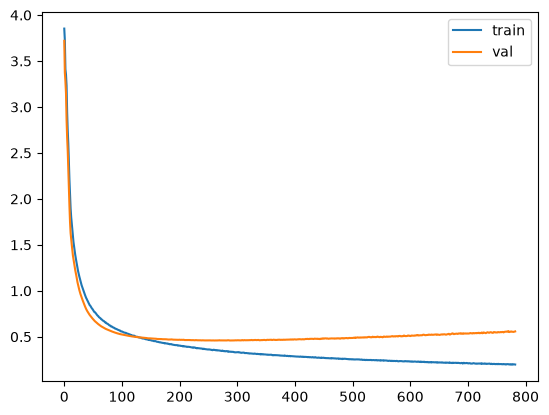

In [54]:
plt.plot(l_emnist, label="train")
plt.plot(val_l_emnist, label="val")
plt.legend()
plt.show()

In [55]:
from sklearn.metrics import accuracy_score

def evaluate_emnist(x):

    model_emnist.eval()

    # Forward
    logits = model_emnist(x)

    # Convertimos logits a probabilidades
    probabilidades = torch.softmax(logits, dim=1)

    # Elegimos la clase con mayor probabilidad
    predicciones = torch.argmax(
        probabilidades,
        dim=1
    )

    return predicciones

In [56]:
y_pred_emnist = evaluate_emnist(
    X_test_emnist_t
)

accuracy_emnist = accuracy_score(
    y_test_emnist_t.cpu().numpy(),
    y_pred_emnist.cpu().numpy()
)

print(f"Accuracy: {accuracy_emnist * 100:.2f}%")

Accuracy: 84.63%


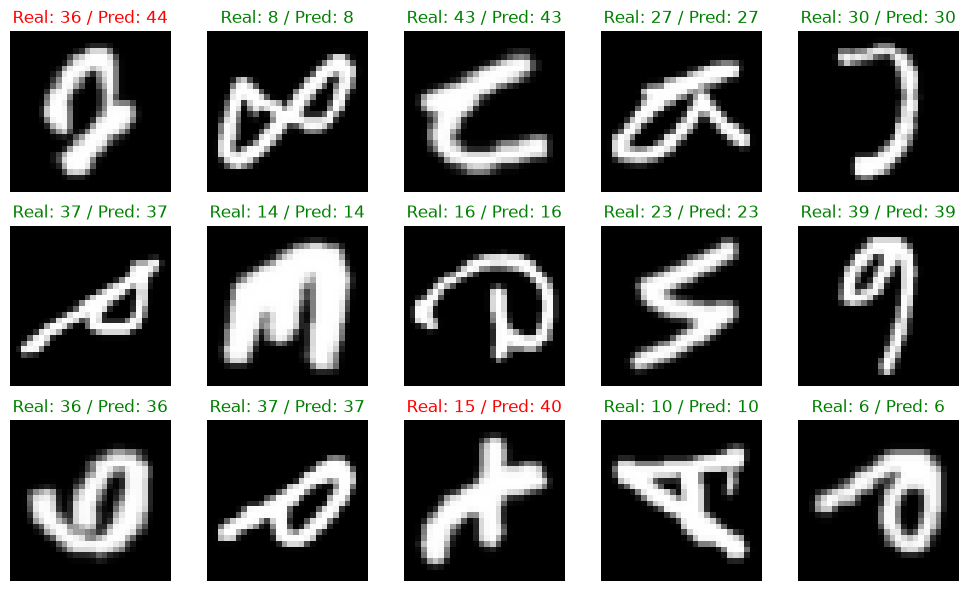

In [57]:
r, c = 3, 5

fig = plt.figure(figsize=(2*c, 2*r))

for _r in range(r):
    for _c in range(c):

        plt.subplot(r, c, _r*c + _c + 1)

        ix = random.randint(0, len(X_test_emnist) - 1)

        img = X_test_emnist[ix]

        y_real = y_test_emnist[ix]

        y_pred = evaluate_emnist(
            torch.tensor(
                [img],
                dtype=torch.float32,
                device="cuda"
            )
        )[0].item()

        plt.imshow(
            img.reshape(28, 28),
            cmap="gray"
        )

        plt.axis("off")

        plt.title(
            f"Real: {y_real} / Pred: {y_pred}",
            color="green" if y_real == y_pred else "red"
        )

plt.tight_layout()
plt.show()